# CNN Encoder-Decoder
This code was originally purpoused for turning images took in the day to nightime images, but the dataset was unpaired and I then had to repurpouse. It now uses the edge to shoes dataset (Edges2Shoes on kaggle). This is a simple CNN that turns images to images using an encoder-decoder architecture. The training code is below.

After running, run the cleanup script. If you have not ran the cleaning script and downloaded all the output, (like I did on my first run) unzip the output (it should be 1.32 GB) then delete everything except for edges-to-shoes.keras.  After that, use the file as an input (in the kaggle IDE, this is what you do. In other IDEs, feel free to edit file paths). Then run the test code.

In [1]:
# Training code

import tensorflow as tf
import cv2
import os
from tqdm import tqdm
import shutil

ssim = lambda y_true, y_pred:1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

img_height, img_width = 256, 256
batch_size = 8

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/balraj98/edges2shoes-dataset/train",
    label_mode=None,
    batch_size=8,
    image_size=(256, 512),
    shuffle=True,         
    seed=123
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/balraj98/edges2shoes-dataset/val",
    label_mode=None,
    batch_size=8,
    image_size=(256, 512),
    shuffle=False
)

def split_and_normalize(batch):
    batch = batch / 255.0
    edges = batch[:, :, :256, :]
    shoes = batch[:, :, 256:, :]
    return (edges, shoes)

train_ds = raw_train_ds.map(split_and_normalize).prefetch(tf.data.AUTOTUNE)
val_ds = raw_val_ds.map(split_and_normalize).prefetch(tf.data.AUTOTUNE)

inputs = tf.keras.layers.Input(shape=(256,256,3))

c1 = tf.keras.layers.Conv2D(64, 3, padding='same')(inputs)
c1 = tf.keras.layers.LeakyReLU()(c1)
c2 = tf.keras.layers.Conv2D(64, 3, padding='same')(c1)
c2 = tf.keras.layers.LeakyReLU()(c2)
p1 = tf.keras.layers.MaxPooling2D()(c2)

c3 = tf.keras.layers.Conv2D(128, 3, padding='same')(p1)
c3 = tf.keras.layers.LeakyReLU()(c3)
c4 = tf.keras.layers.Conv2D(128, 3, padding='same')(c3)
c4 = tf.keras.layers.LeakyReLU()(c4)
p2 = tf.keras.layers.MaxPooling2D()(c4)

b1 = tf.keras.layers.Conv2D(256, 3, padding='same')(p2)
b1 = tf.keras.layers.LeakyReLU()(b1)
b2 = tf.keras.layers.Conv2D(256, 3, padding='same')(b1)
b2 = tf.keras.layers.LeakyReLU()(b2)

u1 = tf.keras.layers.UpSampling2D()(b2)
u2 = tf.keras.layers.Concatenate()([u1, c4])

c5 = tf.keras.layers.Conv2D(128, 3, padding='same')(u2)
c5 = tf.keras.layers.LeakyReLU()(c5)
c6 = tf.keras.layers.Conv2D(128, 3, padding='same')(c5)
c6 = tf.keras.layers.LeakyReLU()(c6)

u3 = tf.keras.layers.UpSampling2D()(c6)
u4 = tf.keras.layers.Concatenate()([u3, c2])

c7 = tf.keras.layers.Conv2D(64, 3, padding='same')(u4)
c7 = tf.keras.layers.LeakyReLU()(c7)

c8 = tf.keras.layers.Conv2D(64, 3, padding='same')(c7)
c8 = tf.keras.layers.LeakyReLU()(c8)

outputs = tf.keras.layers.Conv2D(3, 1, activation='sigmoid', padding='same', dtype='float32')(c8)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), loss=ssim)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/edges-to-shoes.keras", 
    save_best_only=True,         
    monitor="val_loss"
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=10, 
    monitor="val_loss",
    restore_best_weights=True  
)

model.fit(train_ds, epochs=20, callbacks=[early_stopping, checkpoint], validation_data=val_ds)

2026-05-27 17:45:59.767199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779903959.992457      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779903960.056087      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779903960.630810      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779903960.630853      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779903960.630856      23 computation_placer.cc:177] computation placer alr

Found 49825 files.


I0000 00:00:1779904278.177900      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 200 files.
Epoch 1/20


I0000 00:00:1779904284.999759      72 service.cc:152] XLA service 0x784514013bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779904284.999796      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779904285.673687      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/6229 ━━━━━━━━━━━━━━━━━━━━ 31:44:42 18s/step - loss: 0.3972

I0000 00:00:1779904299.935585      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6229/6229 ━━━━━━━━━━━━━━━━━━━━ 842s 132ms/step - loss: 0.3574 - val_loss: 0.3617
Epoch 2/20


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:390: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized: ssim = lambda y_true, y_pred:1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

  return {key: serialize_keras_object(value) for key, value in obj.items()}


6229/6229 ━━━━━━━━━━━━━━━━━━━━ 826s 133ms/step - loss: 0.3572 - val_loss: 0.3617
Epoch 3/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 822s 132ms/step - loss: 0.3571 - val_loss: 0.3617
Epoch 4/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 821s 132ms/step - loss: 0.3571 - val_loss: 0.3617
Epoch 5/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 819s 131ms/step - loss: 0.3572 - val_loss: 0.3617
Epoch 6/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 820s 132ms/step - loss: 0.3571 - val_loss: 0.3617
Epoch 7/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 818s 131ms/step - loss: 0.3571 - val_loss: 0.3617
Epoch 8/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 819s 132ms/step - loss: 0.3572 - val_loss: 0.3617
Epoch 9/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 819s 131ms/step - loss: 0.3571 - val_loss: 0.3617
Epoch 10/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 820s 132ms/step - loss: 0.3572 - val_loss: 0.3617
Epoch 11/20
6229/6229 ━━━━━━━━━━━━━━━━━━━━ 820s 132ms/step - loss: 0.3571 - val_loss: 0.3617


In [2]:
# Testing if dataset exists
import os
os.listdir("/kaggle/input/datasets/balraj98/edges2shoes-dataset")

['val', 'metadata.csv', 'train']

In [3]:
# Cleanup the output code
# Run directly after training code
import shutil
import os

train_X = "/kaggle/working/train_X"
train_y = "/kaggle/working/train_y"

val_X = "/kaggle/working/val_X"
val_y = "/kaggle/working/val_y"
paths = [train_X, train_y, val_X, val_y]

for path in paths:
    if os.path.exists(path):
        shutil.rmtree(path)
    else:
        print(f'{path} does not exist. Have you ran the training code?')

/kaggle/working/train_X does not exist. Have you ran the training code?
/kaggle/working/train_y does not exist. Have you ran the training code?
/kaggle/working/val_X does not exist. Have you ran the training code?
/kaggle/working/val_y does not exist. Have you ran the training code?


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Path loading completed
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Image Loaded and processed


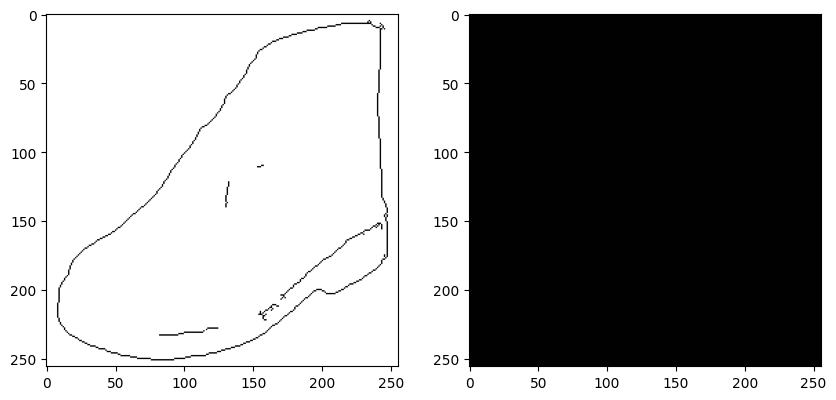

In [4]:
##### import tensorflow as tf
from PIL import Image
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import seaborn
import cv2

model = tf.keras.models.load_model("/kaggle/input/models/zacharypotishko/edges-to-shoes-model-v5/keras/default/1/edges-to-shoes-2.keras")

img = cv2.imread("/kaggle/input/datasets/balraj98/edges2shoes-dataset/train/10000_AB.jpg")
    
h, w, _ = img.shape
midpoint = w // 2
    
left = img[:, :midpoint]
left = cv2.cvtColor(left, cv2.COLOR_BGR2RGB)
right = img[:, midpoint:]

resized_img = cv2.resize(left, (256, 256))

print("Path loading completed")

input_tensor = resized_img[None, :, :, :] / 255
output = model.predict(input_tensor)

print("Image Loaded and processed")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(resized_img)
axes[1].imshow(output.squeeze() / 255)
plt.show()